In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')

In [2]:
import sys
print(sys.executable)

import matplotlib
import pandas
import numpy
import seaborn

print(matplotlib.__version__)
print(pandas.__version__)
print(numpy.__version__)

c:\Program Files\Python312\python.exe
3.11.0
3.0.3
2.5.0


In [3]:
import torch

print("Torch:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA Version:", torch.version.cuda)

Torch: 2.11.0+cu128
CUDA Available: True
GPU: NVIDIA GeForce RTX 4060
CUDA Version: 12.8


In [4]:
# Load Datasets
df = pd.read_csv('./data/raw/finguard-fraud-detection-dataset.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
# Inspect the dataset

print("\n=== Data Info ===")
df.info()

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Statistical Summary ===")
print(df.describe())


=== Data Info ===
<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB

=== Missing Values ===
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

=== Statistical Summary ===
               step        amount  oldbalanceOrg  newbalanceOrig  \
count  6.362620e+06  6.362620e+06   6.362620e+06    6.362620e+06   
mean   2.433972e+02 

In [6]:
df.describe(include='object')

,type,nameOrig,nameDest
count,6362620,6362620,6362620
unique,5,6353307,2722362
top,CASH_OUT,C2098525306,C1286084959
freq,2237500,3,113


In [7]:
duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates:,}")

if duplicates > 0:
    print(f"Duplicate Percentage: {duplicates/len(df)*100:.4f}%")
else:
    print("No duplicate rows found.")

Duplicate Rows: 0
No duplicate rows found.


In [8]:
overview = pd.DataFrame({
    "Metric":[
        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Rows",
        "Fraud Cases",
        "Fraud Rate (%)"
    ],
    "Value":[
        len(df),
        len(df.columns),
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        df.isFraud.sum(),
        round(df.isFraud.mean()*100,4)
    ]
})

print(overview.to_string(index=False))

        Metric        Value
          Rows 6362620.0000
       Columns      11.0000
Missing Values       0.0000
Duplicate Rows       0.0000
   Fraud Cases    8213.0000
Fraud Rate (%)       0.1291


In [9]:
# missing values
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

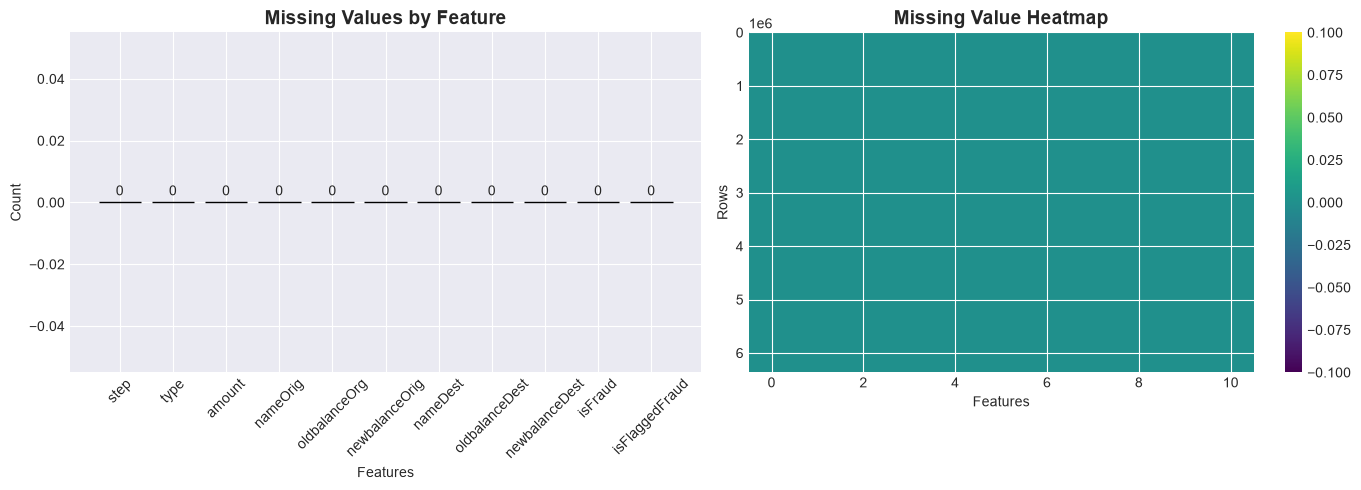

In [10]:
# Bar plot for missing values
missing = df.isnull().sum()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars = axes[0].bar(missing.index, missing.values, color='skyblue', edgecolor='black')
axes[0].set_title('Missing Values by Feature', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Features')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    axes[0].annotate(f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

# Heatmap for missing values
im = axes[1].imshow(df.isnull(), aspect='auto', cmap='viridis')
axes[1].set_title('Missing Value Heatmap', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Features')
axes[1].set_ylabel('Rows')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.savefig('./reports/figures/missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

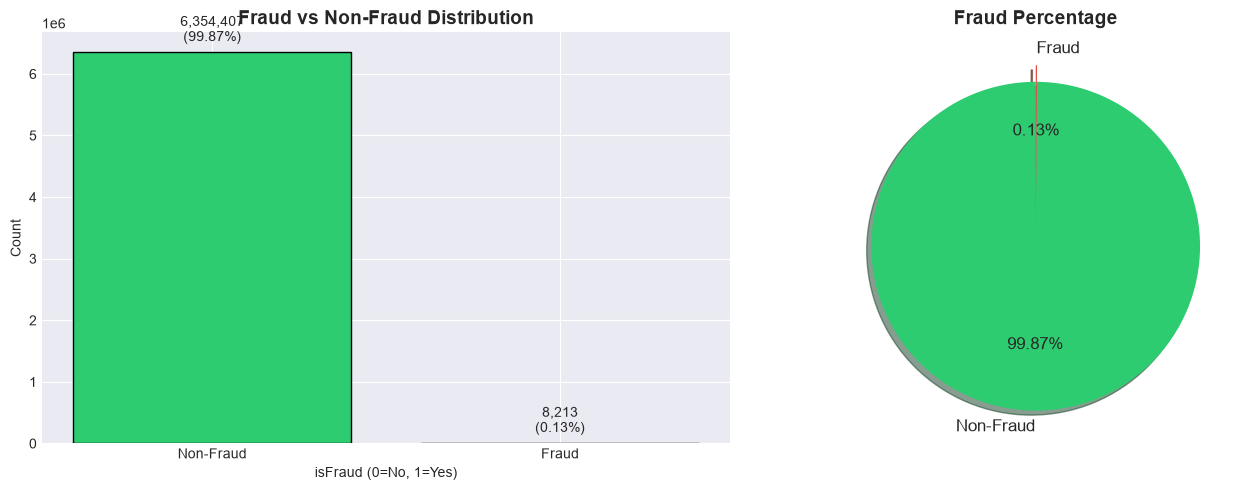


Fraud Cases: 8,213
Non-Fraud Cases: 6,354,407
Fraud Percentage: 0.1291%


In [11]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
fraud_counts = df['isFraud'].value_counts()
bars = axes[0].bar(['Non-Fraud', 'Fraud'], fraud_counts.values, 
                  color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Fraud vs Non-Fraud Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('isFraud (0=No, 1=Yes)')
axes[0].set_ylabel('Count')

# Add percentage labels
total = len(df)
for bar in bars:
    height = bar.get_height()
    percentage = f'{100 * height / total:.2f}%'
    axes[0].annotate(f'{height:,}\n({percentage})',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom')

# Pie chart
colors = ['#2ecc71', '#e74c3c']
explode = (0.05, 0.05)
axes[1].pie(fraud_counts.values, labels=['Non-Fraud', 'Fraud'], 
            autopct='%1.2f%%', colors=colors, explode=explode,
            shadow=True, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Fraud Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('./reports/figures/fraud_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nFraud Cases: {df['isFraud'].sum():,}")
print(f"Non-Fraud Cases: {len(df) - df['isFraud'].sum():,}")
print(f"Fraud Percentage: {(df['isFraud'].sum()/len(df))*100:.4f}%")

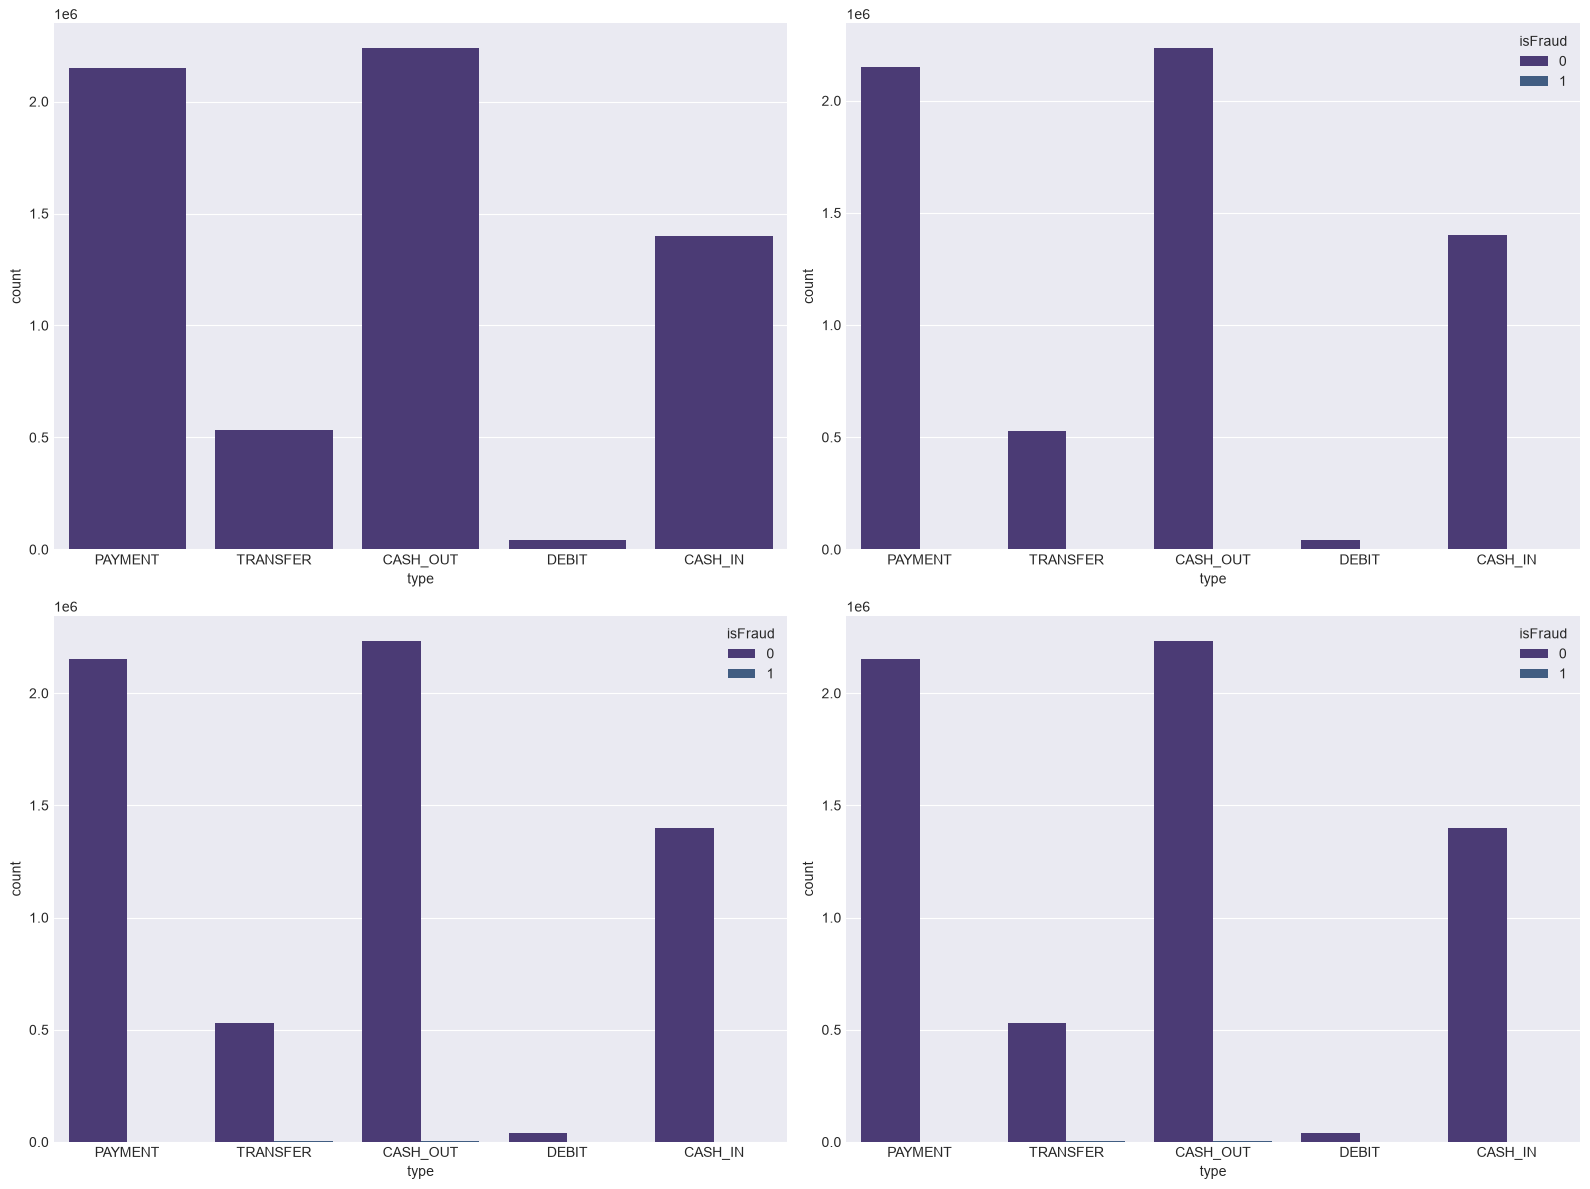

In [12]:
# Transaction type analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.countplot(x='type', data=df, ax=axes[0, 0])
sns.countplot(x='type', hue='isFraud', data=df, ax=axes[0, 1])
sns.countplot(x='type', hue='isFraud', data=df, ax=axes[1, 0])
sns.countplot(x='type', hue='isFraud', data=df, ax=axes[1, 1])
plt.tight_layout()
plt.savefig('./reports/figures/transaction_type.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
# Fraud by transaction type
fraud_by_type = df[df['isFraud'] == 1]['type'].value_counts()
fraud_by_type.sort_values(ascending=False)


type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64

In [14]:
# Fraud rate by transaction type

fraud_by_type = df.groupby('type')['isFraud'].agg(['sum', 'count'])
fraud_by_type['fraud_rate'] = (fraud_by_type['sum'] / fraud_by_type['count']) * 100
fraud_by_type.sort_values('sum', ascending=False)


,sum,count,fraud_rate
type,,,
CASH_OUT,4116,2237500,0.183955
TRANSFER,4097,532909,0.768799
CASH_IN,0,1399284,0.000000
DEBIT,0,41432,0.000000
PAYMENT,0,2151495,0.000000


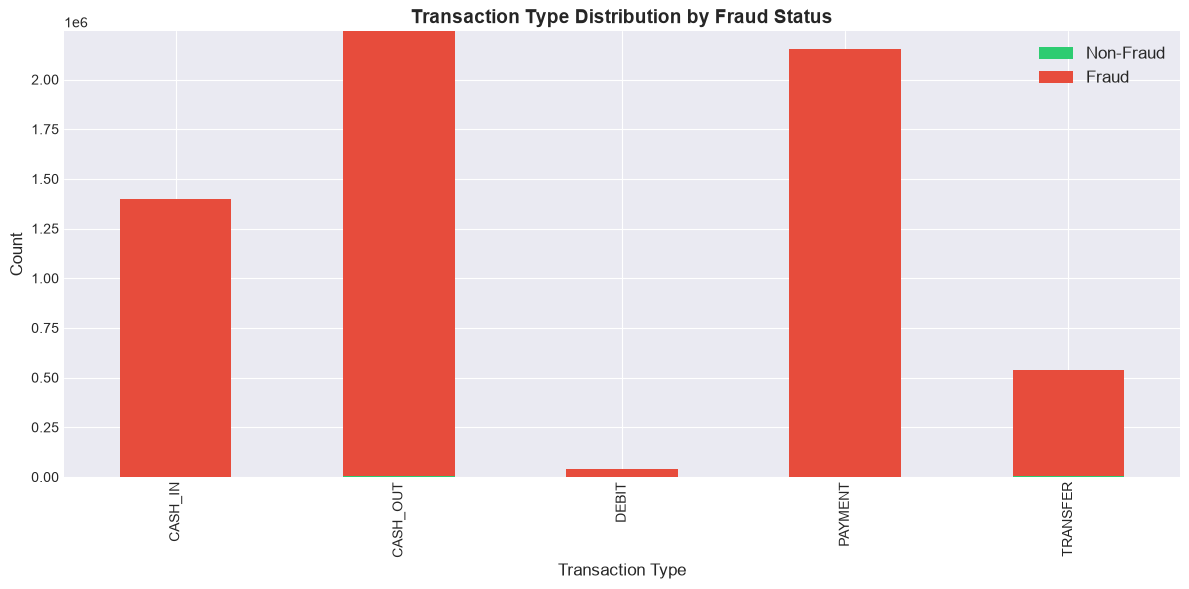

In [15]:
# Stacked transaction plot
fig, ax = plt.subplots(figsize=(12, 6))
fraud_by_type.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Transaction Type Distribution by Fraud Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Transaction Type', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.legend(['Non-Fraud', 'Fraud'], fontsize=12)
plt.tight_layout()
plt.savefig('./reports/figures/transaction_type_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
# cross validation
print("\nFraud by Transaction Type")
print(pd.crosstab(df['type'], df['isFraud']))


Fraud by Transaction Type
isFraud         0     1
type                   
CASH_IN   1399284     0
CASH_OUT  2233384  4116
DEBIT       41432     0
PAYMENT   2151495     0
TRANSFER   528812  4097


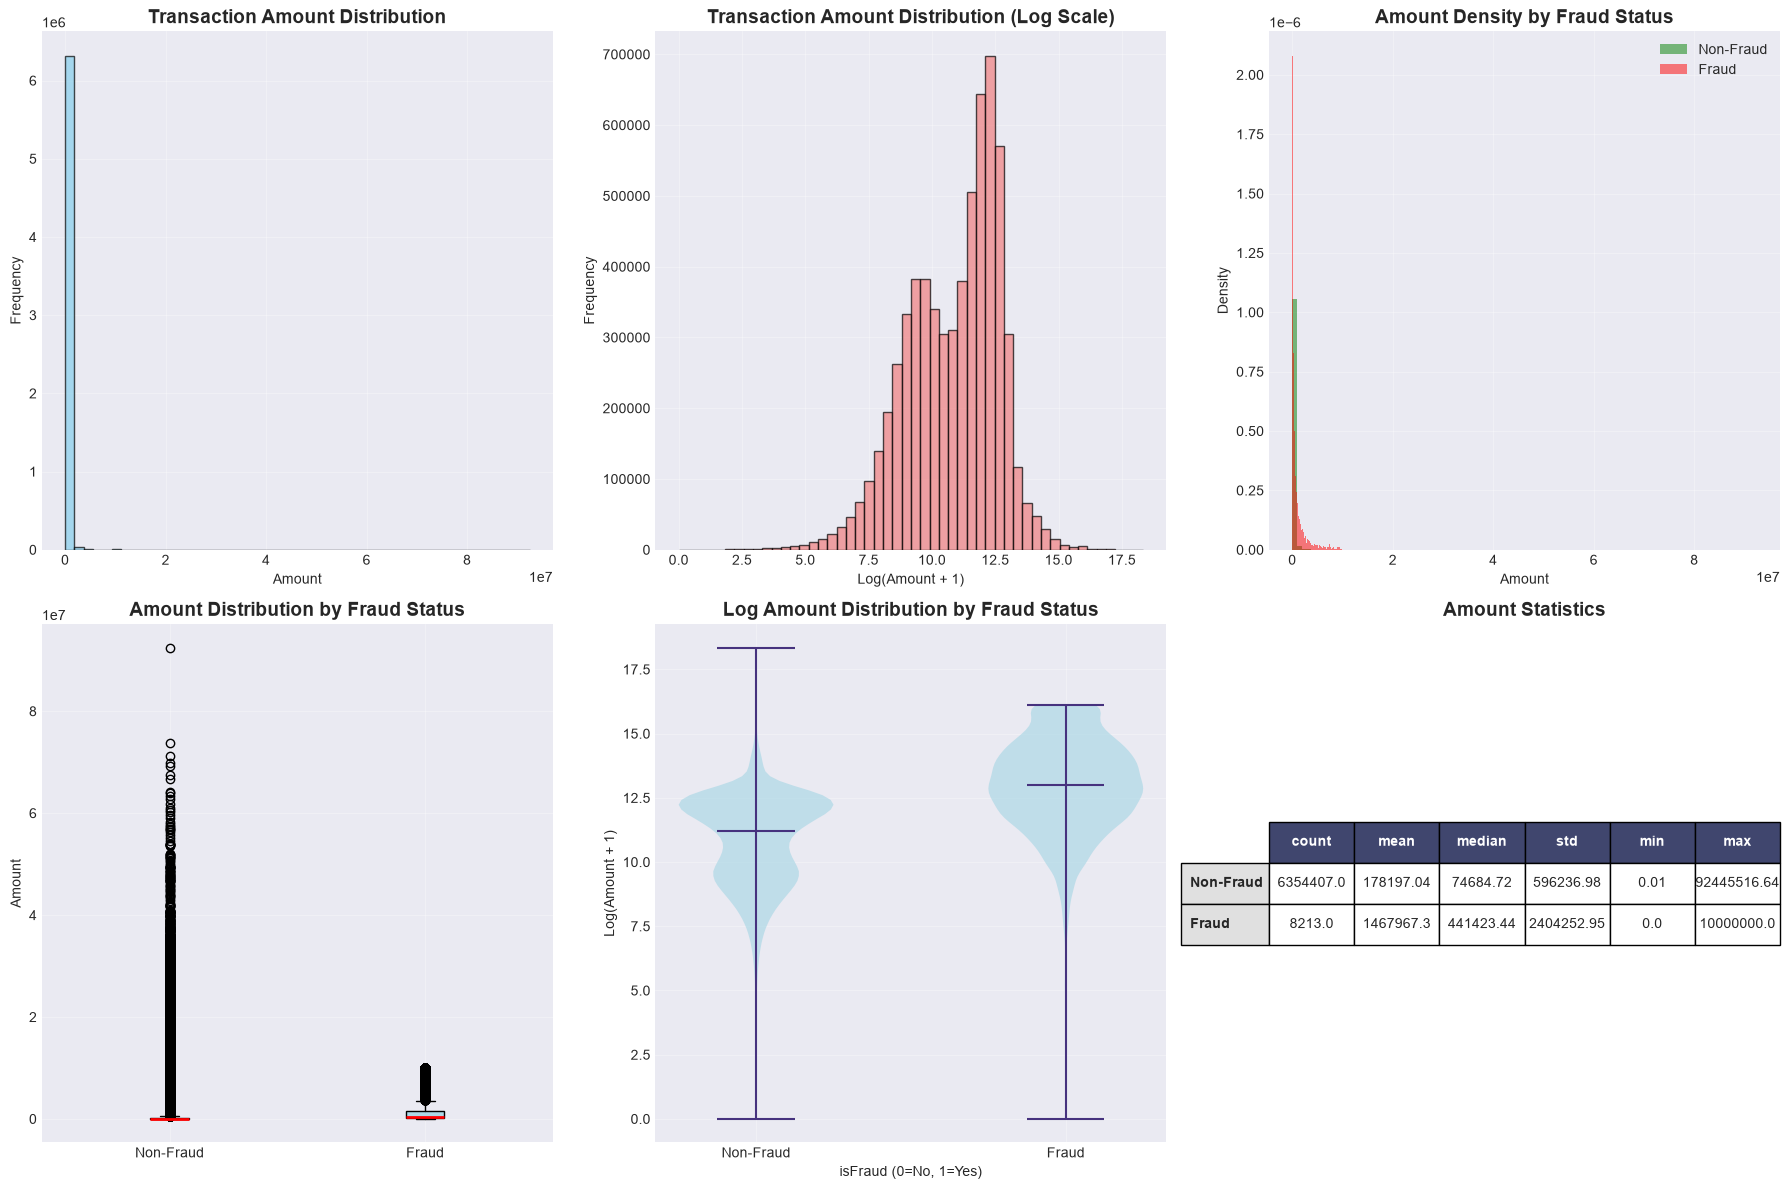


=== Amount Statistics by Fraud Status ===
           count        mean     median         std   min          max
isFraud                                                               
0        6354407   178197.04   74684.72   596236.98  0.01  92445516.64
1           8213  1467967.30  441423.44  2404252.95  0.00  10000000.00


In [17]:
# Transaction amount analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Amount distribution
axes[0, 0].hist(df['amount'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Transaction Amount Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Amount')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# Amount distribution (log scale)
axes[0, 1].hist(np.log1p(df['amount']), bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Transaction Amount Distribution (Log Scale)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Log(Amount + 1)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# KDE plot for amount by fraud status
fraud_amount = df[df['isFraud'] == 1]['amount']
non_fraud_amount = df[df['isFraud'] == 0]['amount']

# Plot KDE for non-fraud
axes[0, 2].hist(non_fraud_amount, bins=100, density=True, alpha=0.5, color='green', label='Non-Fraud')
axes[0, 2].hist(fraud_amount, bins=100, density=True, alpha=0.5, color='red', label='Fraud')
axes[0, 2].set_title('Amount Density by Fraud Status', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Amount')
axes[0, 2].set_ylabel('Density')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Boxplot for amount by fraud status
axes[1, 0].boxplot(
    [non_fraud_amount, fraud_amount],
    tick_labels=['Non-Fraud', 'Fraud'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='red', linewidth=2)
)
axes[1, 0].set_title('Amount Distribution by Fraud Status', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Amount')
axes[1, 0].grid(True, alpha=0.3)

# Violin plot for log amount
parts = axes[1, 1].violinplot([np.log1p(non_fraud_amount), np.log1p(fraud_amount)], 
                              positions=[0, 1], showmeans=False, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('lightblue')
    pc.set_alpha(0.7)
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(['Non-Fraud', 'Fraud'])
axes[1, 1].set_title('Log Amount Distribution by Fraud Status', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('isFraud (0=No, 1=Yes)')
axes[1, 1].set_ylabel('Log(Amount + 1)')
axes[1, 1].grid(True, alpha=0.3)

# Amount statistics table
stats_df = df.groupby('isFraud')['amount'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2)
axes[1, 2].axis('off')
table_data = stats_df.values
row_labels = ['Non-Fraud', 'Fraud']
col_labels = stats_df.columns.tolist()

table = axes[1, 2].table(cellText=table_data, rowLabels=row_labels,
                         colLabels=col_labels, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
axes[1, 2].set_title('Amount Statistics', fontsize=14, fontweight='bold')

# Color the table header and rows
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_facecolor('#40466e')
        cell.set_text_props(color='white', fontweight='bold')
    elif j == -1:
        cell.set_facecolor('#e0e0e0')
        cell.set_text_props(fontweight='bold')

plt.tight_layout()
plt.savefig('./reports/figures/amount_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== Amount Statistics by Fraud Status ===")
print(stats_df)

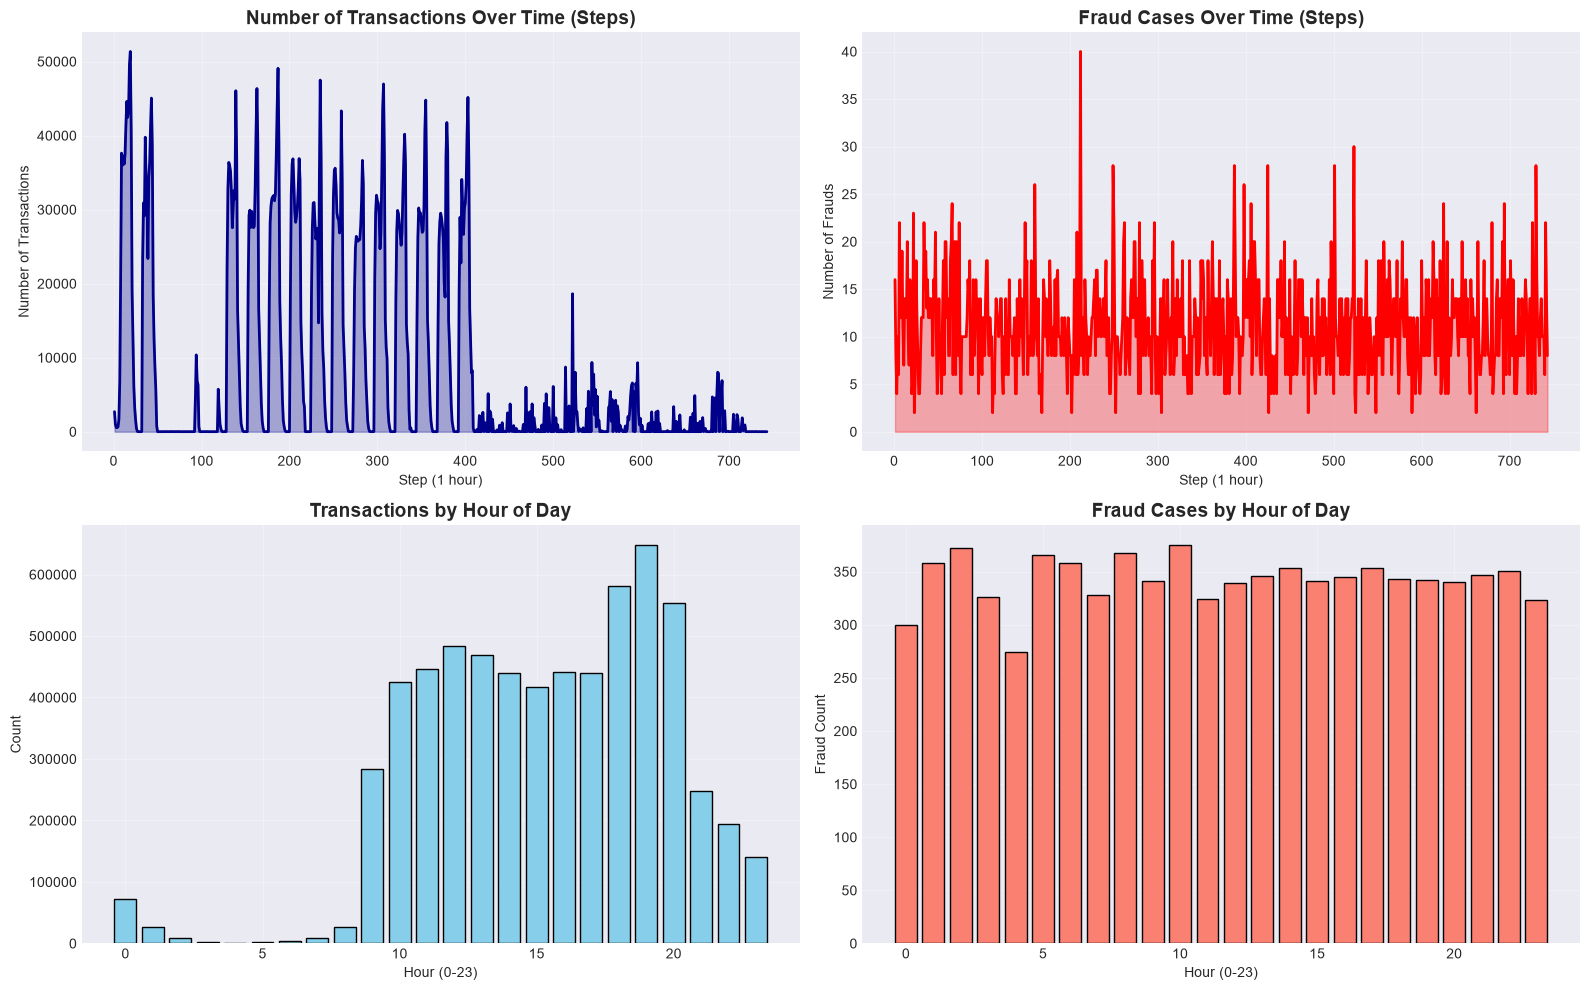

In [18]:
# Create hour feature
df['hour'] = df['step'] % 24

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Transactions over time
time_series = df.groupby('step').size()
axes[0, 0].plot(time_series.index, time_series.values, linewidth=2, color='darkblue')
axes[0, 0].fill_between(time_series.index, time_series.values, alpha=0.3, color='darkblue')
axes[0, 0].set_title('Number of Transactions Over Time (Steps)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Step (1 hour)')
axes[0, 0].set_ylabel('Number of Transactions')
axes[0, 0].grid(True, alpha=0.3)

# Fraud over time
fraud_time = df[df['isFraud'] == 1].groupby('step').size()
axes[0, 1].plot(fraud_time.index, fraud_time.values, linewidth=2, color='red')
axes[0, 1].fill_between(fraud_time.index, fraud_time.values, alpha=0.3, color='red')
axes[0, 1].set_title('Fraud Cases Over Time (Steps)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Step (1 hour)')
axes[0, 1].set_ylabel('Number of Frauds')
axes[0, 1].grid(True, alpha=0.3)

# Transactions by hour
hour_counts = df['hour'].value_counts().sort_index()
bars = axes[1, 0].bar(hour_counts.index, hour_counts.values, 
                      color='skyblue', edgecolor='black')
axes[1, 0].set_title('Transactions by Hour of Day', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Hour (0-23)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].grid(True, alpha=0.3)

# Fraud by hour
fraud_hour = df[df.isFraud == 1].groupby('hour').size()
bars = axes[1, 1].bar(fraud_hour.index, fraud_hour.values, 
                      color='salmon', edgecolor='black')
axes[1, 1].set_title('Fraud Cases by Hour of Day', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Hour (0-23)')
axes[1, 1].set_ylabel('Fraud Count')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./reports/figures/time_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


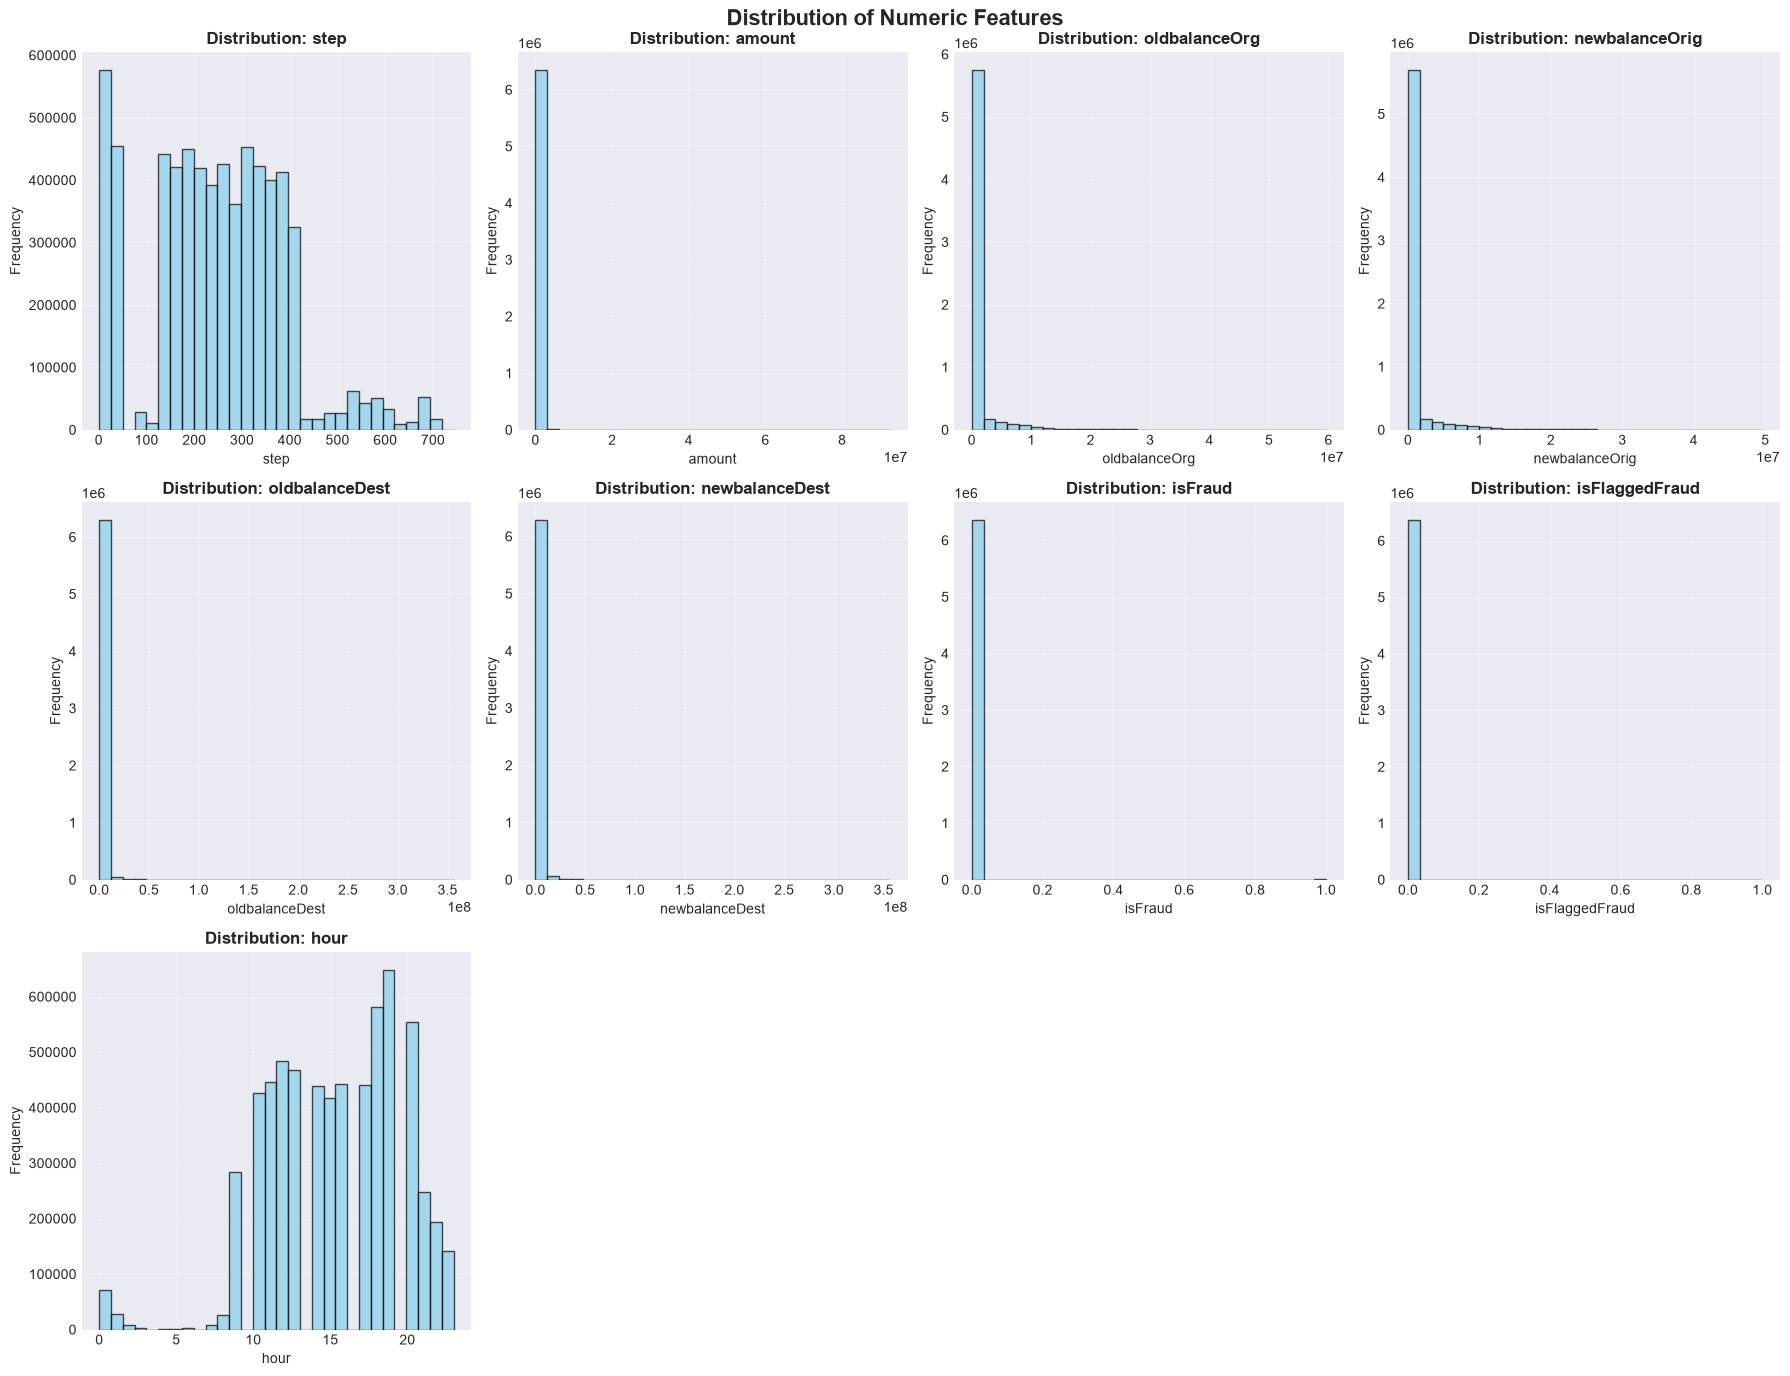

In [19]:
# Numeric feature correlation
numeric_cols = df.select_dtypes(include=np.number).columns

fig, axes = plt.subplots(3, 4, figsize=(18, 14))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        axes[idx].hist(df[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution: {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(True, alpha=0.3)

# Remove empty subplots
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Distribution of Numeric Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('./reports/figures/numeric_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

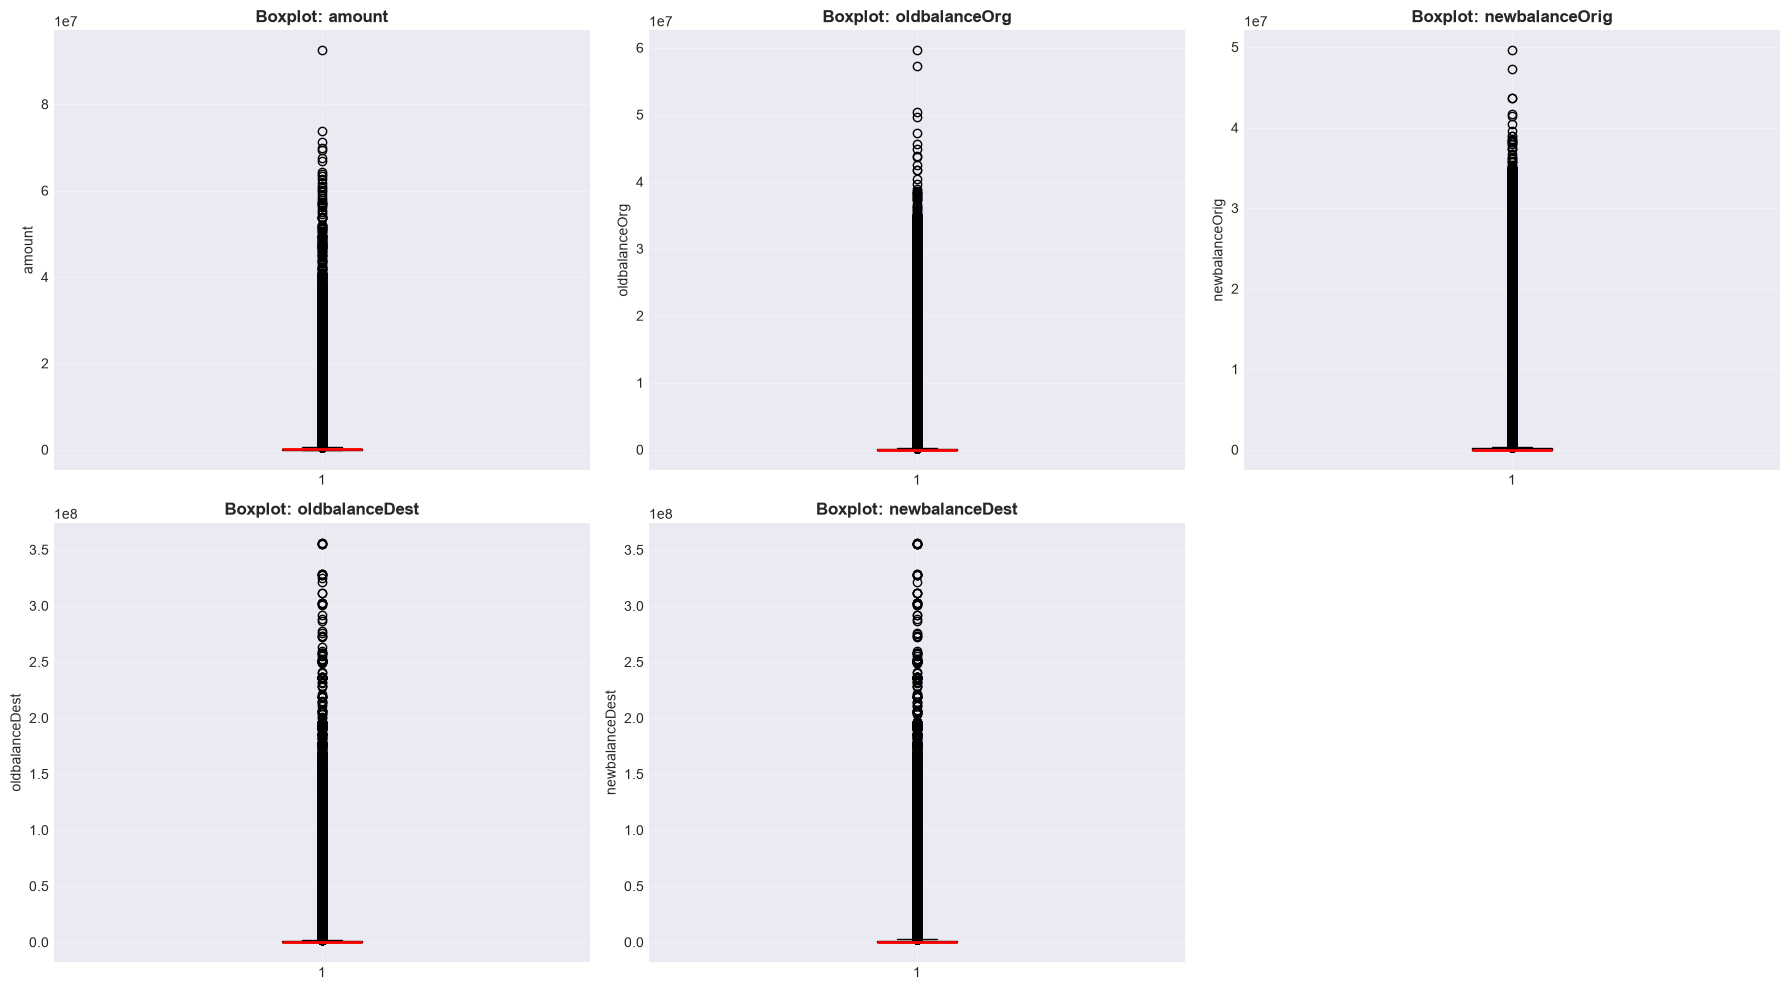

In [20]:
# Outlier detection 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

for idx, col in enumerate(cols):
    if idx < len(axes.flatten()):
        bp = axes.flatten()[idx].boxplot(df[col], patch_artist=True,
                                         boxprops=dict(facecolor='lightblue'),
                                         medianprops=dict(color='red', linewidth=2))
        axes.flatten()[idx].set_title(f'Boxplot: {col}', fontsize=12, fontweight='bold')
        axes.flatten()[idx].set_ylabel(col)
        axes.flatten()[idx].grid(True, alpha=0.3)

# Remove empty subplot
axes.flatten()[-1].axis('off')

plt.tight_layout()
plt.savefig('./reports/figures/outlier_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()


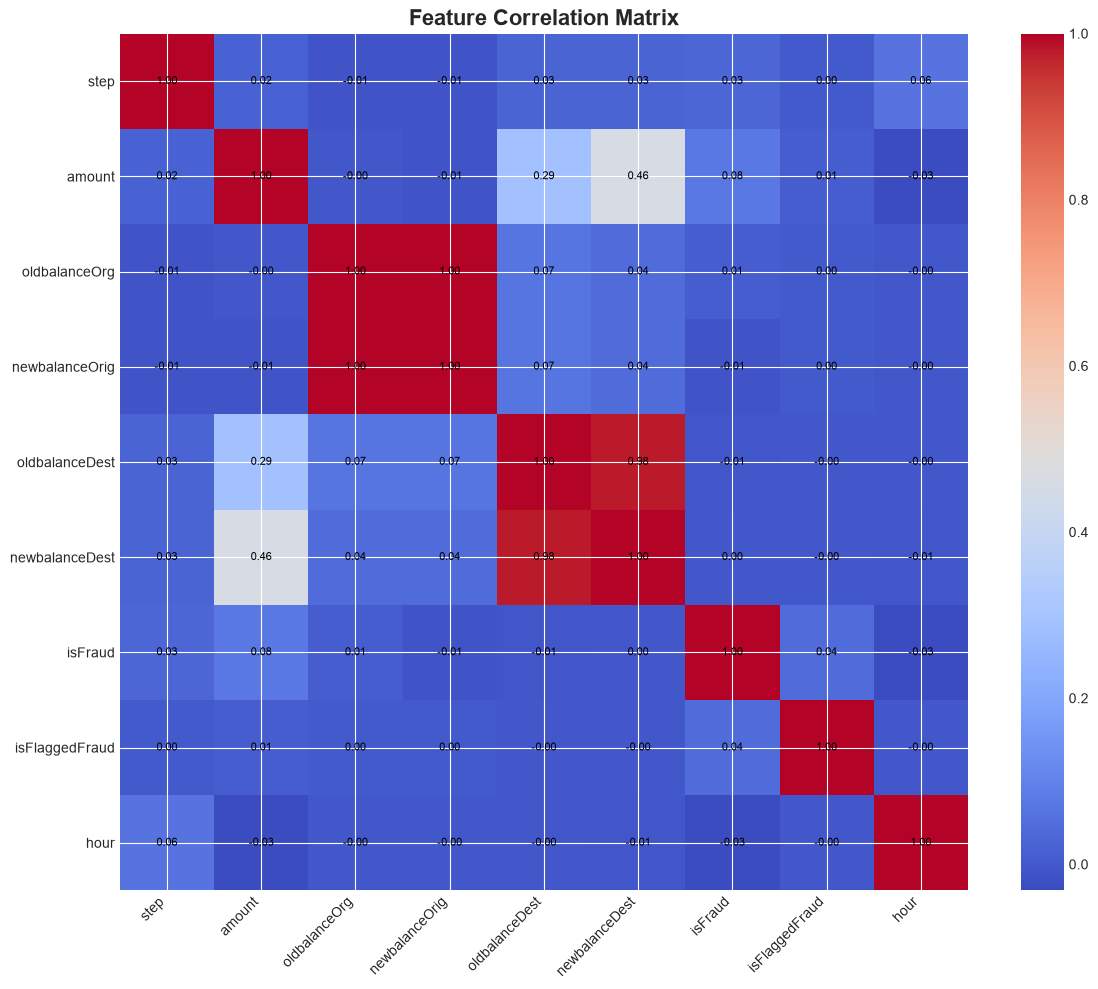

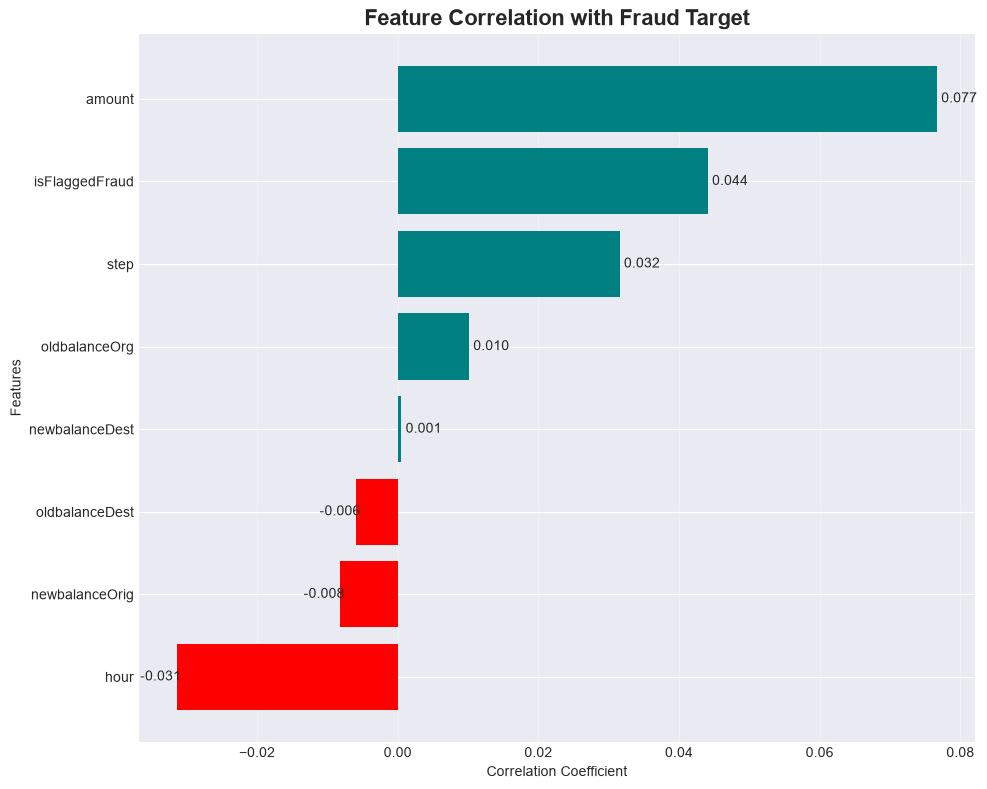


=== Feature Correlation with Fraud ===
hour             -0.031403
newbalanceOrig   -0.008148
oldbalanceDest   -0.005885
newbalanceDest    0.000535
oldbalanceOrg     0.010154
step              0.031578
isFlaggedFraud    0.044109
amount            0.076688
isFraud           1.000000
Name: isFraud, dtype: float64


In [21]:
# Correlation Analysis
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Full correlation matrix
fig, ax = plt.subplots(figsize=(12, 10))
correlation_matrix = numeric_df.corr()
im = ax.imshow(correlation_matrix, cmap='coolwarm', aspect='auto')

# Add colorbar
plt.colorbar(im, ax=ax)

# Set tick labels
ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(correlation_matrix.columns)

# Add correlation values in cells
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        text = ax.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=8)

ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('./reports/figures/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation with target
corr = numeric_df.corr()['isFraud'].sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['red' if x < 0 else 'teal' for x in corr.drop('isFraud').values]
bars = ax.barh(corr.drop('isFraud').index, corr.drop('isFraud').values, color=colors)
ax.set_title('Feature Correlation with Fraud Target', fontsize=16, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.set_ylabel('Features')
ax.grid(True, alpha=0.3, axis='x')

# Add values on bars
for bar in bars:
    width = bar.get_width()
    ax.annotate(f'{width:.3f}',
                xy=(width, bar.get_y() + bar.get_height()/2),
                xytext=(3, 0),
                textcoords="offset points",
                ha='left' if width > 0 else 'right',
                va='center')

plt.tight_layout()
plt.savefig('./reports/figures/correlation_with_target.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== Feature Correlation with Fraud ===")
print(corr)



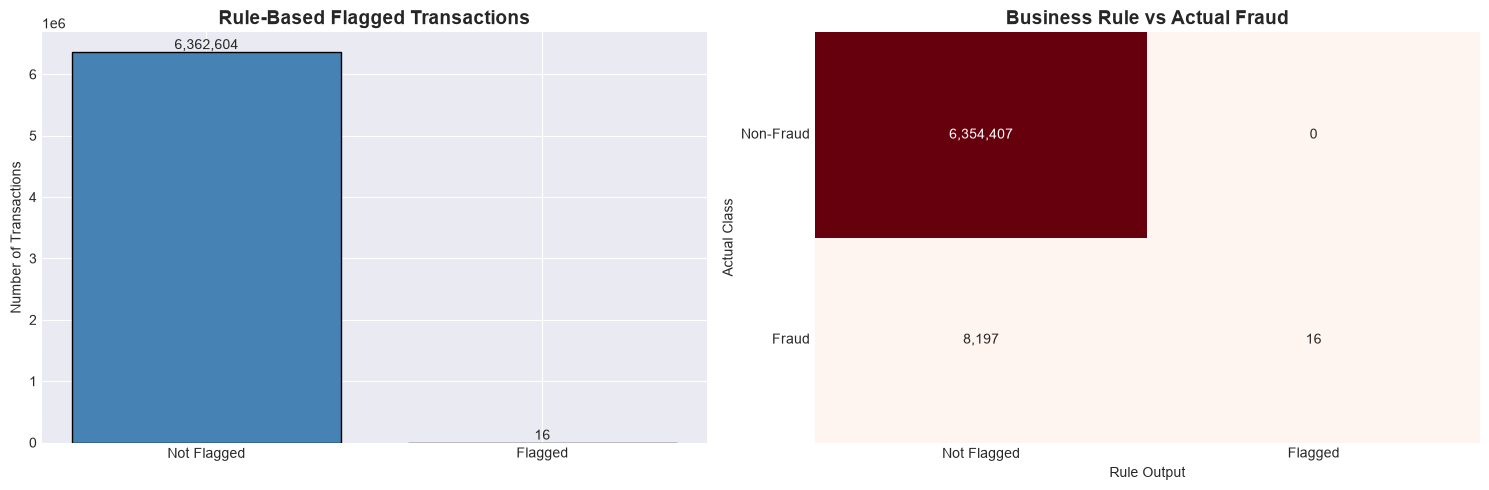

In [22]:

# Rule-Based Fraud Detection Analysis

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Flagged vs Not Flagged


flagged_counts = df["isFlaggedFraud"].value_counts().sort_index()

bars = axes[0].bar(
    ["Not Flagged", "Flagged"],
    flagged_counts.values,
    color=["steelblue", "crimson"],
    edgecolor="black"
)

axes[0].set_title("Rule-Based Flagged Transactions", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Number of Transactions")

for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )


# Confusion Matrix of Business Rule

cm = pd.crosstab(df["isFraud"], df["isFlaggedFraud"])

sns.heatmap(
    cm,
    annot=True,
    fmt=",",
    cmap="Reds",
    cbar=False,
    ax=axes[1]
)

axes[1].set_title("Business Rule vs Actual Fraud", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Rule Output")
axes[1].set_ylabel("Actual Class")

axes[1].set_xticklabels(["Not Flagged", "Flagged"])
axes[1].set_yticklabels(["Non-Fraud", "Fraud"], rotation=0)

plt.tight_layout()

plt.savefig(
    "./reports/figures/rule_based_detection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
fraud_count = df.groupby("type")["isFraud"].sum()

highest_fraud_type = fraud_count.idxmax()
highest_fraud_count = fraud_count.max()

fraud_by_type = df.groupby('type')['isFraud'].sum()
fraud_rate = df.groupby('type')['isFraud'].mean() * 100

fraud_flagged = pd.crosstab(df["isFraud"], df["isFlaggedFraud"])


In [ ]:

print("\n📌 Dataset Overview:")
print(f"  - Total Transactions: {len(df):,}")
print(f"  - Features: {len(df.columns)}")
print(f"  - Fraud Rate: {(df['isFraud'].sum()/len(df))*100:.4f}% (HIGHLY IMBALANCED)")
print(f"  - Missing Values: {df.isnull().sum().sum()}")
print(f"  - Duplicate Rows: {df.duplicated().sum():,}")

print("\n📌 Transaction Types:")
print(f"  - Most Common: {df['type'].value_counts().index[0]} ({df['type'].value_counts().values[0]:,})")
print(f"  - Highest Fraud Count: {highest_fraud_type} ({highest_fraud_count:,} frauds)")
print(f"  - Highest Fraud Rate: {fraud_rate.idxmax()} ({fraud_rate.max():.2f}%)")

print("\n📌 Amount Insights:")
print(f"  - Fraud Amount Mean: {df[df['isFraud']==1]['amount'].mean():.2f}")
print(f"  - Non-Fraud Amount Mean: {df[df['isFraud']==0]['amount'].mean():.2f}")
print(f"  - Fraud Amount Median: {df[df['isFraud']==1]['amount'].median():.2f}")
print(f"  - Non-Fraud Amount Median: {df[df['isFraud']==0]['amount'].median():.2f}")

print("\n📌 Time Insights:")
print(f"  - Peak Transaction Step: {time_series.idxmax()} (hour)")
print(f"  - Peak Fraud Step: {fraud_time.idxmax()} (hour)")
print(f"  - Peak Transaction Hour: {df['hour'].value_counts().index[0]}")
print(f"  - Peak Fraud Hour: {fraud_hour.idxmax()}")

print("\n📌 Flagged Fraud:")
print(f"  - Total Flagged: {df['isFlaggedFraud'].sum()}")
print(f"  - Correctly Flagged: {fraud_flagged.loc[1,1]} out of {df['isFraud'].sum():,} frauds")
print(f"  - Flagging Accuracy: {fraud_flagged.loc[1,1]/df['isFraud'].sum()*100:.2f}%")
print(f"  - False Positives: {fraud_flagged.loc[0,1]:,}")

print("\n📌 Correlation Insights:")
top_corr = corr.drop('isFraud').abs().sort_values(ascending=False)
positive_corr = corr.drop('isFraud').sort_values(ascending=False).head(3)
negative_corr = corr.drop('isFraud').sort_values(ascending=True).head(3)
print(f"  - Top Positive Correlations: {positive_corr.index.tolist()} ({positive_corr.values.round(3)})")
print(f"  - Top Negative Correlations: {negative_corr.index.tolist()} ({negative_corr.values.round(3)})")

print("\n⚠️ Key Points for Modeling:")
print("  1. Dataset is heavily imbalanced (fraud < 1%)")
print("  2. 'oldbalanceOrg' and 'newbalanceOrig' are strongly correlated")
print("  3. 'oldbalanceDest' and 'newbalanceDest' are also correlated")
print("  4. Transaction type is important - need to encode it carefully")
print("  5. Consider log transformation for 'amount' due to skewness")
print("  6. 'isFlaggedFraud' is a derived feature - handle with caution")
print("  7. Consider creating time-based features from 'step'")
print("  8. Features like 'step' may not be equally important for all transactions")


📌 Dataset Overview:
  - Total Transactions: 6,362,620
  - Features: 12
  - Fraud Rate: 0.1291% (HIGHLY IMBALANCED)
  - Missing Values: 0
  - Duplicate Rows: 0

📌 Transaction Types:
  - Most Common: CASH_OUT (2,237,500)
  - Highest Fraud Count: CASH_OUT (4,116 frauds)
  - Highest Fraud Rate: TRANSFER (0.77%)

📌 Amount Insights:
  - Fraud Amount Mean: 1467967.30
  - Non-Fraud Amount Mean: 178197.04
  - Fraud Amount Median: 441423.44
  - Non-Fraud Amount Median: 74684.72

📌 Time Insights:
  - Peak Transaction Step: 19 (hour)
  - Peak Fraud Step: 212 (hour)
  - Peak Transaction Hour: 19
  - Peak Fraud Hour: 10

📌 Flagged Fraud:
  - Total Flagged: 16
  - Correctly Flagged: 16 out of 8,213 frauds
  - Flagging Accuracy: 0.19%
  - False Positives: 0

📌 Correlation Insights:
  - Top Positive Correlations: ['amount', 'isFlaggedFraud', 'step'] ([0.077 0.044 0.032])
  - Top Negative Correlations: ['hour', 'newbalanceOrig', 'oldbalanceDest'] ([-0.031 -0.008 -0.006])

⚠️ Key Points for Modeling:
  

In [31]:
flagged = df['isFlaggedFraud'].sum()
total_fraud = df['isFraud'].sum()
detected = df[(df['isFraud'] == 1) & (df['isFlaggedFraud'] == 1)].shape[0]
missed = total_fraud - detected
false_positive = df[(df['isFraud'] == 0) & (df['isFlaggedFraud'] == 1)].shape[0]
print("BUSINESS RULE BASELINE")

print(f"Transactions Flagged : {flagged:,}")
print(f"Actual Frauds        : {total_fraud:,}")
print(f"Frauds Detected      : {detected:,}")
print(f"Missed Frauds        : {missed:,}")
print(f"False Positives      : {false_positive:,}")
print(f"Detection Rate       : {detected/total_fraud*100:.2f}%")

BUSINESS RULE BASELINE
Transactions Flagged : 16
Actual Frauds        : 8,213
Frauds Detected      : 16
Missed Frauds        : 8,197
False Positives      : 0
Detection Rate       : 0.19%
